# Lab 8: The Lennard-Jones Potential: Molecules and Scattering


### Objectives
1.  Simulate a 1D system governed by the Lennard-Jones (L-J) potential using `scipy.integrate.solve_ivp`.
2.  Write a function to calculate the total energy of the system.
3.  Use **energy conservation** as a tool to validate the numerical accuracy of the ODE solver.
4.  Investigate the difference between **bound states** (a stable molecule) and **unbound states** (atomic scattering) by changing the system's total energy.

### The Physics Model

The L-J potential $V(r)$ describes the interaction between two neutral atoms. It has a strong **repulsive** force at short distances and a weak **attractive** force at long distances.

The potential energy given in Lennard-Jones (1931) is:
$$ V(r) = 4\epsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right] $$
where the 6 is coming from van der Waals forces (specifically Londer dispersion forces) and 12 is from experiments. Here $\epsilon$ is the depth of the potential well $\sigma$ is the distance where the particle-particle potential energy is zero, and $r$ is the separation between two particles.

The force is the negative derivative of the potential, $F(r) = -dV/dr$:
$$ F(r) = 24 \frac{\epsilon}{\sigma} \left[ 2\left(\frac{\sigma}{r}\right)^{13} - \left(\frac{\sigma}{r}\right)^7 \right] $$

The total energy $E = K + V(r) = \frac{1}{2}mv^2 + V(r)$ determines the state:

* If **$E < 0$**, the atoms are trapped in the potential well. This is a **bound state** (a molecule).
* If **$E > 0$**, the atoms have enough energy to escape. This is an **unbound state** (scattering).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [ ]:
# --- Constants for Argon (Ar) ---
# We will model two Argon atoms.
# We fix one atom at r=0 and simulate the motion of the other.
epsilon = 1.65e-21  # L-J well depth (J)
sigma = 3.40e-10    # L-J distance scale (m)
m = 6.63e-26        # Mass of one Argon atom (kg)

### Task 1: Define the Physics Functions

Complete the three functions below.
1.  `lj_potential`: Calculates $V(r)$.
2.  `lj_force`: Calculates $F(r)$.
3.  `dSdt`: This tells the ODE solver how the state vector $\mathbf{S} = [r, v_r]$ changes over time. Remember, $d\mathbf{S}/dt = [v_r, F(r)/m]$.


#### The `dSdt` Function:
The function `scipy.integrate.solve_ivp` is a powerful but "dumb" tool. It doesn't know physics (like $F=ma$). It only knows how to solve a system of **first-order differential equations**.

Our physics is built on a **second-order** differential equation:
$$F = ma \implies F(x) = m \frac{d^2x}{dt^2}$$

Our job is to trick the solver by turning this *one* 2nd-order equation into *two* 1st-order equations. We do this by creating a **state vector**, $\mathbf{S}$, that describes the system at any instant `t`.

**Step 1: Define the State Vector `S`**

We define our state as a list (or array) containing position and velocity:
$\mathbf{S} = [ \text{position}, \text{velocity} ]$
In our code, this is:
`S = [x, vx]`
So, `S[0] = x` and `S[1] = vx`.

**Step 2: Define the Derivative of the State Vector, `dSdt`**

The solver needs a function that, given the state `S` at time `t`, returns its derivative, $d\mathbf{S}/dt$. This returned array *must* have the same shape as `S`.

$d\mathbf{S}/dt = \left[ \frac{d(\text{S}[0])}{dt}, \frac{d(\text{S}[1])}{dt} \right]$

Let's find each part:
1.  **First element: `d(S[0])/dt`**
    * `S[0]` is position, `x`.
    * The derivative of position is $\frac{dx}{dt}$, which is just... velocity, `vx`.
    * Where is `vx` stored in our state vector? It's `S[1]`.
    * So, the first element we return is `vx`.

2.  **Second element: `d(S[1])/dt`**
    * `S[1]` is velocity, `vx`.
    * The derivative of velocity is $\frac{dv_x}{dt}$, which is acceleration, `ax`.
    * How do we find `ax`? From our physics model! $F = ma \implies a_x = F(x) / m$.
    * Since $x$ is `S[0]`, we can get the force using our `lj_force` function: `force = lj_force(S[0], ...)`
    * So, the second element we return is `ax = force / m`.

**Putting it all together:**

The solver sends our function: `S = [x, vx]`
Our function takes that and must return: `dS/dt = [vx, ax]`


In [ ]:
# Write a function for the force
def lj_force(r):
  return 24 * epsilon * ((2 * ((sigma / r)**13)) - ((sigma / r)**7))/sigma
#Write a function for the potential
def lj_potential(r):
  return 4 * epsilon * (((sigma / r)**12) - ((sigma / r)**6))
#Write a function
def dSdt(t, S):
    x = S[0]
    vx = S[1]

    #  check for r=0 to avoid division error, though it's unlikely
    if x == 0:
        return [0, 0]

    force = lj_force(S[0])# force function you wrote
    ax = force/m# acceleration

    return [vx, ax]

### Task 2: Define the Energy Function

To check our solver, we must see if it conserves energy. Write a function that takes the *entire* solution array and calculates the total energy $E = K + V$ at every point in time.

In [ ]:
# --- Task 2: Define the Energy Function ---
# (Updated to return K, V, and E separately)

def get_energies(S_array, m, epsilon, sigma):
    """
    Calculates K, V, and E_total for each step in a solution.
    S_array is [N, 2] where S_array[:, 0] = r and S_array[:, 1] = v_r
    """
    r = S_array[:, 0]#m
    v = S_array[:, 1]#m/s

    # Calculate Kinetic (K) and Potential (V) energy
    K =m*v**2/2#
    V = lj_potential(r)#
    E_total = K+V#

    return K, V, E_total

## Part 1: Bound State (A Molecule)

Let's place the atom *inside* the potential well, near the equilibrium point ($r \approx 1.12\sigma$), with a small initial velocity. Its total energy will be $E = K + V < 0$.


## How to Plan Your `solve_ivp` Call

`solve_ivp` stands for "Solve Initial Value Problem." Think of it as a powerful engine. To make it work, you just need to give it four key pieces of information:

1.   Your Function:** The very first argument is the name of the function it should call at every step.
     `dSdt`

2.  **The Time Span (`t_span`):** When should the simulation start and stop? This is a list of two numbers: `[t_start, t_end]`.
    * `t_span = [0, 5e-11]` (e.g., from 0 to 50 picoseconds)

3.  **The Initial State (`S0`):** What are the starting position and velocity? This *must* match the format of your state vector `S = [r, v]`.
    * `S0 = [x0_bound, v0_bound]` (e.g., `[1.12*sigma, 10.0]`)

4.  **Where to Save (`t_eval`):** The solver will take thousands of tiny steps for accuracy, but we don't want to save all of them. `t_eval` is a `numpy` array of the *exact* time points where we want to record the solution.
    * example `t_eval = np.linspace(0, t_end, 500)` (e.g., "Give me 500 evenly spaced points from your solution.")

5. The method for solving. The default is `RK45`, the Runge-Kutta 4. It'll adapat to the `rtol` and `atol` you select. `DOP853` is another option. This is the Dormand-Prince 8(5,3) algorithm which is a higher order Runge-Kutta method. It's slower but more accurate. Then there is `BDF` the backward differentiation formula, which is helpful for stiff systems, meaning there are multiple different timescales happening at once. We don't need that here. There is also `LSODA` which has automatic stiffness detection, and `Radau`which is the implicit Runge-Kutta method of order 5.

##Fine tuning
How do we know the solver is correct? For a conservative system like this, **total energy must be conserved**.

A good simulation will show very little energy drift. A bad one will show energy being created or destroyed, which is unphysical.

The `rtol` (relative tolerance) and `atol` (absolute tolerance) arguments are the "accuracy knobs" for the solver.

* `rtol`: Relative tolerance. `rtol=1e-8` tells the solver "try to be accurate to about 8 significant digits."
* `atol`: Absolute tolerance. `atol=1e-12` tells the solver "if the value is near zero, its error should be no larger than 1e-12."

### What `solve_ivp` Returns: The Solution Object (`sol`)

When `solve_ivp` is finished, it hands you back a "solution object" (which we call `sol`). This object contains all the results. The two most important parts are:

* `sol.t`: The array of time points you asked for (this will be identical to your `t_eval` array).
* `sol.y`: The state vector `S` at each of those time points.

**The Shape of `sol.y`**

`solve_ivp` organizes its output `sol.y` in a `(num_variables, num_timesteps)` format. For us, that's `(2, 500)`.
* `sol.y[0]` is the *entire array* of all 500 positions.
* `sol.y[1]` is the *entire array* of all 500 velocities.

This might be bit awkward for your `calculate_total_energy` function, which might expect an `(N, 2)` array (a list of `[x, v]` pairs), depending on how you write it.

You can easily fix this by **transposing** the array with `.T`:

`S_array = sol.y.T`

This flips the array from `(2, 500)` to `(500, 2)`, which is exactly what tiy might need.
* `S_array[:, 0]` is now the column of positions.
* `S_array[:, 1]` is now the column of velocities.

In [ ]:
# --- Task 3: Simulate a Bound State ---

# Initial conditions (at the potential minimum)
x0_bound = 1.12 * sigma
v0_bound = 50.0 # Give it a small kick (m/s)
S0_bound = [x0_bound, v0_bound]#
# Simulation time
t_end = 5e-11 # 50 picoseconds
t_points = np.arange(0, t_end, 1e-13) # make a numpy array for time from 0 to t_end maybe linspace would work...
t_span = [0,5e-11]
# Run the solver
# We use 'RK45' which is a good general-purpose solver
# rtol and atol control the accuracy. 1e-8 is reasonably strict.
# rtol is the relative tolerance and atol is the absolute tolerance.
sol_bound = solve_ivp(dSdt, t_span, S0_bound, t_eval = t_points, rtol=1e-8, method = 'RK45')
S_array = sol_bound.y.T
print("Bound state simulation complete.")

Bound state simulation complete.


### Task 4: Analyze the Bound State

Now, let's plot the motion and check the energy conservation.

-1.5668347863307495e-21


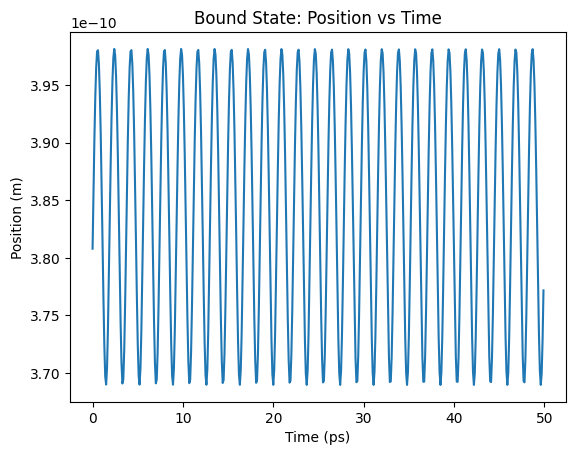

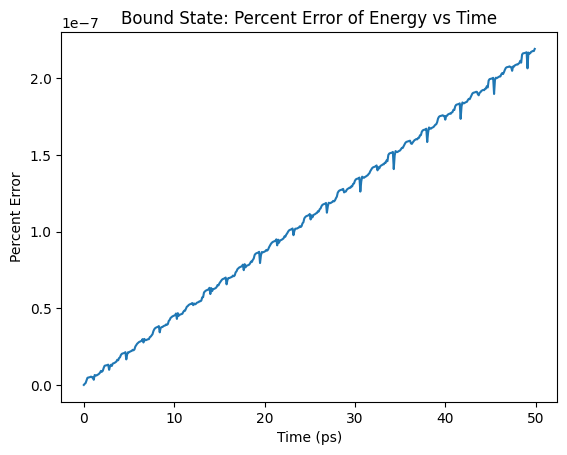

In [ ]:
# Get the [N, 2] solution array by transposing the solver's output


# Calculate the energy at each step using your energy function
K_bound, V_bound, E_bound = get_energies(S_array, m, epsilon, sigma)#
E0_bound = E_bound[0] # Get the initial energy
#Print out the initial energy
print(E0_bound)
# Plot time vs separation. it might be helpful to scale the x values and label x in pico seconds rather than plot seconds.
#make sure to provide a title and axis labels.
plt.figure()
plt.plot(sol_bound.t * 1e12, S_array[:,0]) # Use sol_bound.t and scale to picoseconds
plt.title("Bound State: Position vs Time")
plt.xlabel("Time (ps)")
plt.ylabel("Position (m)")
plt.show()
# Plot the percent error of the calculated energy from initial energy again with time on x.
rerr_bound = (E_bound-E0_bound)/E0_bound
plt.figure()
plt.plot(sol_bound.t * 1e12, rerr_bound) # Use sol_bound.t and scale to picoseconds
plt.title("Bound State: Percent Error of Energy vs Time")
plt.xlabel("Time (ps)")
plt.ylabel("Percent Error")
plt.show()

## Part 2: Unbound State (Scattering)

Now, let's start the atom far away ($V \approx 0$) with a high initial velocity ($K > 0$). Its total energy $E = K + V \approx K$ will be positive.

In [ ]:
# --- Task 5: Simulate an Unbound State ---

# Initial conditions
x0_unbound = 10 * sigma  # Start far away
v0_unbound = -150.0      # Fire it at the other atom (m/s)
S0_unbound = [x0_unbound, v0_unbound]

# Use the same time settings
t_end = 5e-11 # 50 picoseconds

# Run the solver
sol_unbound = solve_ivp(dSdt, t_span, S0_unbound, t_eval = t_points, rtol = 1e-8, method = 'RK45')#
S_array_unbound = sol_unbound.y.T
print("Unbound state simulation complete.")

Unbound state simulation complete.


7.458684000066e-22


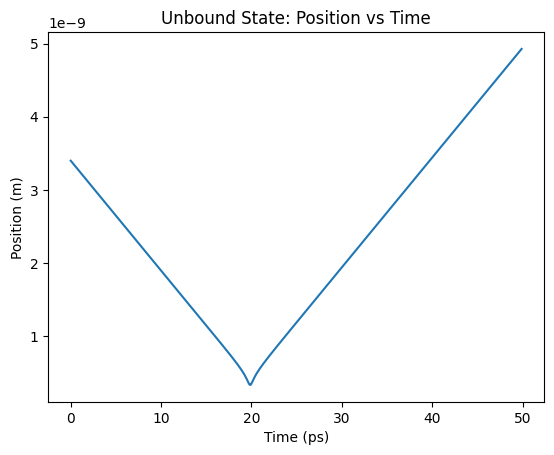

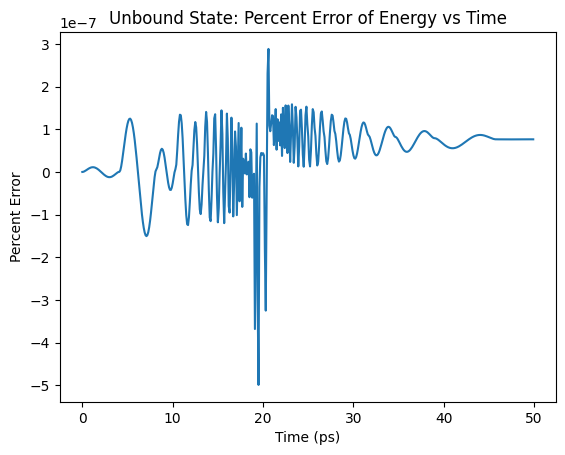

In [ ]:
# --- Task 6: Analyze the Unbound State ---

# Get the [N, 2] solution array


# Calculate the energy at each step
K_unbound, V_unbound, E_unbound = get_energies(S_array_unbound, m, epsilon, sigma)#
E0_unbound = E_unbound[0] # Get the initial energy
#print the initial energy
print(E0_unbound)
plt.figure()
plt.plot(sol_unbound.t * 1e12, S_array_unbound[:,0]) # Use sol_bound.t and scale to picoseconds
plt.title("Unbound State: Position vs Time")
plt.xlabel("Time (ps)")
plt.ylabel("Position (m)")
plt.show()
# Plot the percent error of the calculated energy from initial energy again with time on x.
rerr_unbound = (E_unbound-E0_unbound)/E0_unbound
plt.figure()
plt.plot(sol_unbound.t * 1e12, rerr_unbound) # Use sol_bound.t and scale to picoseconds
plt.title("Unbound State: Percent Error of Energy vs Time")
plt.xlabel("Time (ps)")
plt.ylabel("Percent Error")
plt.show()


Now make a plot of total energy, potential, and kinetic energy vs time for both the bound and unbound state. You might want to use subplots for this.

### How `plt.subplot()` Works (Creating a Grid of Plots)

Think of `plt.figure()` as creating a single, blank canvas. The `plt.subplot()` command is like drawing a grid on that canvas and then telling Python which box in the grid you want to draw in *next*.

The command always takes three numbers:

`plt.subplot(rows, cols, index)`

* **`rows`**: The total number of rows of plots you want in your grid.
* **`cols`**: The total number of columns of plots you want in your grid.
* **`index`**: The "plot number" you want to make **active**. The index starts at `1` in the top-left corner and increases to the right.

---
#### Example from Our Lab:

We want two plots side-by-side. This means we need a grid with **1 row** and **2 columns**.

+-----------+-----------+ | | | | Plot 1 | Plot 2 | | | | +-----------+-----------+ (1, 2, 1) (1, 2, 2)

**1. Creating the First (Left) Plot:**

When you first call:
```python
plt.subplot(1, 2, 1)
```

You are telling Matplotlib:
Create a grid that is 1 row high and 2 columns wide."

*  "Create a grid that is 1 row high and 2 columns wide."
*   "Make the 1st plot in that grid the active one."

All `plt.plot()`, `plt.title()`, `plt.xlabel()`, etc. commands that you type after this line will apply only to this first (left) plot.

Then when you call
```python
plt.subplot(1, 2, 2)
```
You are telling Matplotlib:
Create a grid that is 1 row high and 2 columns wide."

*  "Keep using that same 1 row, 2 column grid."
*   "Now, make the 2nd plot in that grid the active one."

(500, 2)


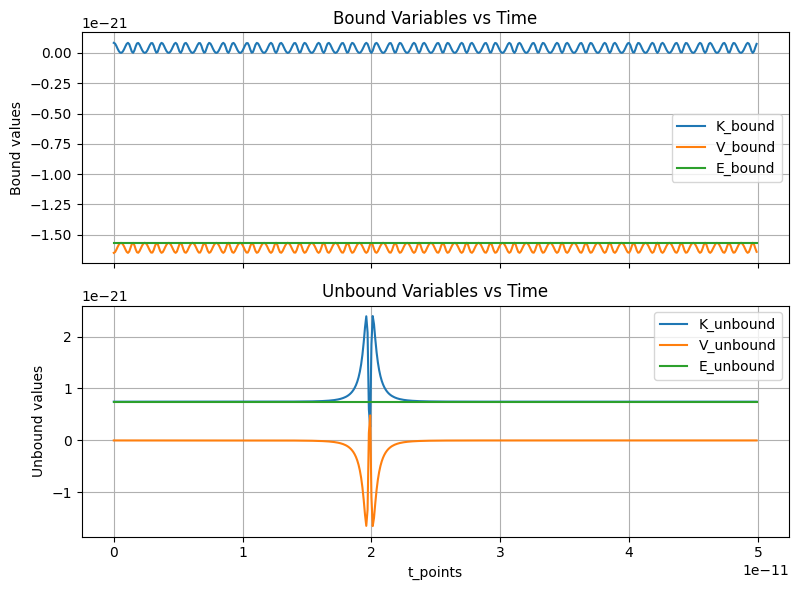

In [ ]:

# --- Part 5: Plotting Energy Components vs. Time ---

# Get the solution data
print(np.shape(S_array_unbound))

# Calculate the K, V, and E for both simulations


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.plot(t_points, K_bound, label='K_bound')
ax1.plot(t_points, V_bound, label='V_bound')
ax1.plot(t_points, E_bound, label='E_bound')
ax1.set_ylabel('Bound values')
ax1.set_title('Bound Variables vs Time')
ax1.legend()
ax1.grid(True)

ax2.plot(t_points, K_unbound, label='K_unbound')
ax2.plot(t_points, V_unbound, label='V_unbound')
ax2.plot(t_points, E_unbound, label='E_unbound')
ax2.set_xlabel('t_points')
ax2.set_ylabel('Unbound values')
ax2.set_title('Unbound Variables vs Time')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


# Subplot 1: Bound State. Plot all three energies and use label and legends.

# Hint: Depending on your numbers you might want something like plt.ylim(-2e-21, 2e-21) to see oscillations

# Subplot 2: Unbound State

#Hint: Dpeending on your numbers you might want something like  plt.ylim(-2e-21, 8e-21) # Set y-limit to see the interaction
#plt.tight_layout() #nice for formatting
#Hint because I sometimes forget this, you will need to include this at the end plt.show()

## Analysis Questions

**1. Compare Simulations:** Look at your two "Position" plots.
   * Describe the motion of the **bound state**. Why is this "bound"? (Hint: What does the $r/\sigma$ value do over time?)
   * Describe the motion of the **unbound state**. Why is this "unbound"? (Hint: What happens to the particle after it gets close to $r=0$?)
   * What was the sign of the total energy $E$ for each case? (See the printed output). How does this confirm your plots?

**2. Test the Solver (Energy Conservation):** Go back to **Task 3 (Bound State)** and change the solver tolerances to be very *loose*:
   `rtol=1e-1, atol=1e-3`
   * Rerun the cells for Part 1. What happens to the "Energy Conservation (Bound)" plot? Does the energy still look physically correct?
   * What does this tell you about trusting a simulation just because it "runs" without errors? Why is checking for conservation of energy so important?

  **3. Physical Connection (Repulsion vs. Attraction):**
   * In your lab on Sgr A*, the force was *always* attractive ($F \propto -1/r^2$). How does the Lennard-Jones *force* ($F(r)$) fundamentally differ?
   * Based on the L-J potential graph, at what separation (e.g., $r > 1.12\sigma$ or $r < 1.12\sigma$) is the force attractive (pulling the atom back)? At what separation is it repulsive (pushing it away)?
   * How does this repulsive force explain why the "scattering" particle "bounces" back in the unbound case, rather than just falling into the center like in the gravity simulation?